In [1]:
from maskvar.maskseg_build_everything import (
    build_cocolvis_dataset,
    build_hqseg44k_dataset,
    build_maskvar_flex,
    build_maskvar_flex_5_stages,
    build_maskvar_flex_mobile_5_stages,
    build_var_image_encoder,
    build_prompt_encoder,
    build_sam_image_encoder,
)
import torch
import torch.nn.functional as F
from maskvar.datasets import (
    LvisDataset,
    HQSeg44KTestDataset,
    HQSeg44KTrainDataset,
    MaskLevelDataset,
    MaskLevelDatasetRandom,
    MaskLevelDatasetDummy,
)
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
import json

In [2]:
device = 'cuda:0'

In [3]:
def visualize_mask(image, layers, instances_info, alpha=0.5):
    plt.imshow(image // 2)
    # for inst_id, inst_info in instances_info.items():   
    #     if inst_info.parent is None:
    #         masked_data = np.ma.masked_where(layers[:, :, inst_info.mapping[0]] == 0, layers[:, :, inst_info.mapping[0]])
    #         plt.imshow(masked_data, alpha=alpha)
    for l in range(layers.shape[-1]):
        masked_data = np.ma.masked_where(layers[:, :, l] == 0, layers[:, :, l])
        plt.imshow(masked_data, alpha=alpha, cmap='tab20c')
    plt.show()

In [4]:
from maskvar.models.sam import PromptEncoder

vqvae, maskvar, sam_image_encoder = build_maskvar_flex_mobile_5_stages('../out/out_vqvae_5_stages_v1/ckpt/vqvae_single_epoch_50.pth', '../ckpt/mobile_sam.pt', device=device)
maskvar.init_block_mask()

# maskvar_ckpt = torch.load('test-maskvar_flex_mobile_5_stages-3/ar-ckpt-last.pth', map_location=device)
maskvar_ckpt = torch.load('../test_out/test-maskvar_flex_mobile_12_debug/ar-ckpt-last.pth', map_location=device)
maskvar.load_state_dict(maskvar_ckpt['trainer']['var_wo_ddp'])


[constructor]  ==== (fusing_add_ln=0/4 ==== 
    [VAR config ] embed_dim=256, num_heads=4, depth=4, mlp_ratio=4
    [drop ratios ] drop_rate=0.1, drop_path_rate=0.1 (tensor([0.0000, 0.0333, 0.0667, 0.1000]))



<All keys matched successfully>

In [5]:
train_set, val_set = build_hqseg44k_dataset('../data/sam-hq')

mask_level_dataset = MaskLevelDatasetRandom(train_set, sam_encoder=sam_image_encoder, device=device)

data_iter = iter(mask_level_dataset)

Loading DIS5K/DIS-VD: 100%|██████████| 464/464 [00:00<00:00, 1435219.07it/s]


In [6]:
image, image_embed_sam, single_mask_normalized, single_mask = next(data_iter)

In [7]:
from maskvar.utils.clicker import init_clicks, predict_next_click, to_sam_format

single_mask_cpu = single_mask.cpu().numpy()

click_list, eroded_mask, dt = init_clicks(single_mask_cpu[0], num_random_clicks=2)

print(click_list)

coords, labels = to_sam_format(click_list, pad_size=13)
prompt_points_coords = torch.Tensor(coords).to(device)
prompt_points_labels = torch.Tensor(labels).to(device)

# prompt_points_coords = [[[150, 150]]]
# prompt_points_labels = [[1]]

# prompt_points_coords = torch.Tensor(prompt_points_coords).to(device)
# prompt_points_labels = torch.Tensor(prompt_points_labels).to(device)

label_B = torch.zeros(1, dtype=torch.long).to(device)

[(np.int64(107), np.int64(142), 1), (np.int64(162), np.int64(79), 1)]


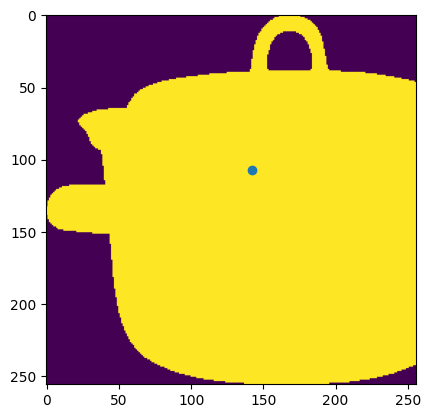

In [8]:
plt.imshow(single_mask.cpu().squeeze(0))
plt.scatter(click_list[0][1], click_list[0][0])

In [9]:
gt_mask = single_mask_normalized.unsqueeze(0)
print(gt_mask.shape)
gt_mask_ids = vqvae.img_to_idxBl(gt_mask)
x_BLCv_wo_first_l = vqvae.quantize.idxBl_to_var_input(gt_mask_ids)

torch.Size([1, 1, 256, 256])


In [10]:
logits = maskvar.forward(label_B=label_B, x_BLCv_wo_first_l=x_BLCv_wo_first_l, sam_image_embedding=image_embed_sam.unsqueeze(0), points_coords=prompt_points_coords.unsqueeze(0), points_labels=prompt_points_labels.unsqueeze(0))

In [11]:
from maskvar.models.helpers import sample_with_top_k_top_p_
import torchvision
from PIL import Image
import numpy as np

In [12]:
idx = sample_with_top_k_top_p_(logits, top_k=1, num_samples=1)[:, :, 0]

In [13]:
# v_patch_nums=(1, 2, 4, 8, 12, 16, 20, 24, 28, 32)
v_patch_nums = (1, 8, 16, 24, 32)

indices = []
sum = 0
for i, pn in enumerate(v_patch_nums):
    indices.append(idx[:, sum:sum+pn*pn].to(device))
    sum += pn*pn


In [14]:
for ind in gt_mask_ids:
    print(ind.shape, ind)

torch.Size([1, 1]) tensor([[2367]], device='cuda:0')
torch.Size([1, 64]) tensor([[ 651, 2969, 2969, 2969, 2852,  142, 3152, 2969, 2969, 2969, 1486, 2907,
         3324, 3891, 3506,  918, 2666, 1463, 2367, 2367, 2907, 2907, 2907, 1548,
         2969, 2367, 2367, 2367, 2367, 2367, 2367, 1548,  466, 1548, 1463, 2367,
         2367, 2367, 2367, 1548,  651, 2970, 2367, 1548, 2367, 2367, 2367, 1548,
         2969, 2519, 1463, 2367, 2367, 1463, 2367, 1548, 4072, 4072,  651,  918,
         1548, 1548,  447, 2367]], device='cuda:0')
torch.Size([1, 256]) tensor([[4072, 1952, 2519, 2519, 4072, 3324, 2666,  447, 3398,  550, 2145,  549,
         3641, 2102, 3084, 2970, 3860, 2519, 2666, 2367, 2519, 2969, 1952,  321,
         3913, 3773, 2489, 3992,  763, 3386, 1600, 2956, 2367,  820, 1548, 2503,
         2367, 2438,  651, 1636,  504, 2130, 2979, 1198, 1725, 3403,  135, 2519,
          651,  243, 3476, 1345, 1404, 2838, 3860, 2944,  933, 1862, 1345, 1012,
         2364, 1463,  744, 3752, 1952, 2620,

In [15]:
for ind in indices:
    print(ind.shape, ind)

torch.Size([1, 1]) tensor([[2519]], device='cuda:0')
torch.Size([1, 64]) tensor([[2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519]], device='cuda:0')
torch.Size([1, 256]) tensor([[2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519, 2519,
         2519, 2519, 2519, 2519, 2519, 2519,

In [16]:
result = vqvae.idxBl_to_img(indices, same_shape=True)
print(len(indices), indices[-1].shape)
# result_conv = [edge(item) for item in result]
result = [(mask > 0).float() for mask in result]
chw = torchvision.utils.make_grid(torch.cat(result[:], dim=0), nrow=5, padding=1, pad_value=1.0)

chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
chw = Image.fromarray(chw.astype(np.uint8))
chw

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 23.68 GiB of which 28.00 MiB is free. Process 1517532 has 17.22 GiB memory in use. Including non-PyTorch memory, this process has 6.42 GiB memory in use. Of the allocated memory 6.05 GiB is allocated by PyTorch, and 69.84 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

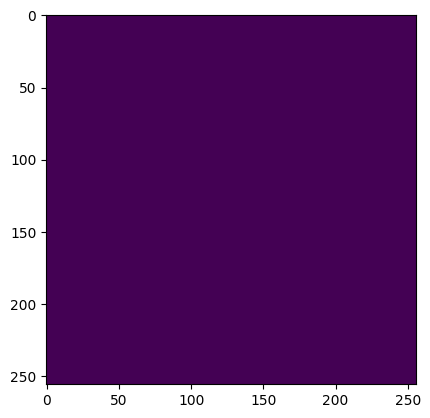

In [ ]:
image_out = maskvar.autoregressive_infer_cfg(B=1, label_B=None, sam_image_embedding=image_embed_sam.unsqueeze(0), points_coords=prompt_points_coords.unsqueeze(0), points_labels=prompt_points_labels.unsqueeze(0), top_k=1)
plt.imshow(image_out[0].permute(1, 2, 0).cpu().numpy() > 0)